# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Statement of use of AI

Claude (Anthropic) was used as a learning and debugging assistant throughout this assignment. Rather than providing complete solutions, AI was used by asking guiding questions, pointing out errors, and explaining concepts to support my learning.

Specific uses included:

- Explaining new concepts such as JSON files, SQLite databases, parameterised queries, API authentication, and KDE plots
- Debugging error messages and identifying syntax issues
- Providing SQL queries for complex joins (Tasks 5c, 6c, 7c) as permitted by the assignment instructions
- Explaining pandas methods such as reset_index(), json_normalize(), and sort_values()
- Advising on best practices such as saving API responses immediately to avoid quota issues

All code was written by me with AI guidance, except for the SQL queries.

## Tasks

### Task 0: Course project dataset exploration 
a) A potential dataset. Provide the name and a link to the source. (0.5p) 
The dataset I  will use is "UN Humanitarian Funding" available on Kaggle: https://www.kaggle.com/datasets/mohitkarangutkar/un-humanitarian-funding. 

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p) 

The dataset is a collection of five interrelated datasets:
Two of them are from the United Nations' primary humanitarian funding mechanisms: the Central Emergency Response Fund (CERF) and the Country-Based Pooled Funds (CBPF). 
In addition, it contains

- Annual CERF allocations broken down by climate disaster type
- Donor contributions to individual Country-Based Pooled Funds
- Humanitarian projects funded through CBPFs globally

The Central Emergency Response Fund (CERF) is one of the fastest and most effective ways to support rapid humanitarian response for people affected by natural disasters and armed conflicts. Established in 2006 by the United Nations, CERF receives voluntary contributions from governments, companies, foundations, and individuals, and disburses funds to humanitarian agencies around the world.

Country-Based Pooled Funds (CBPFs) are UN-managed funds established in countries affected by humanitarian crises. Donors contribute to these pools, and funds are then allocated to humanitarian organizations (UN agencies, NGOs) to respond to the most critical needs in-country.

Coverage: 

- Temporal Coverage Start Date: 01/01/2006
- Temporal Coverage End Date: 02/28/2026
- Geospatial Coverage: Worldwide

I am planning to analyse the data from two angles: donor and recipient. 
- Donor angle will be the Nordic countries: How much they have contributed to humanitarian funding and how it has changed since 2006
- Recipient angle focuses on countries in Africa: Which countries have received the most funding, funding gaps etc.

In [237]:
# c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). 
#This includes computing summary statistics (e.g. using .describe()) and creating at least 2 visualizations of the data. (1p)

#In this cell, I have followed the guidelines in Kaggle to download the datasets with an API token. 

#Install kagglehub package and 'pandas datasets' which directly loads a file from a Kaggle Dataset into a python object (in this case pandas dataframe)


from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()

kaggle_token = os.environ.get("KAGGLE_API_TOKEN")

if kaggle_token:
    print(f"Key loaded: {kaggle_token[:3]}...")
else:
    print("ERROR: KAGGLE_API_TOKEN not found. Check your .env file.")

!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
handle= "mohitkarangutkar/un-humanitarian-funding"
adapter= KaggleDatasetAdapter.PANDAS
cbpf_contributions= "CBPF Contributions.csv"
climate_allocations = "CERF Climate Related Allocations.csv"
donor_allocations = "CERF Donor allocations.csv"
donor_contributions = "CERF Donor contributions.csv"
cbpf_projects = "CBPF Projects.csv"

#download cbpf_contributions
os.environ["KAGGLE_API_TOKEN"] = kaggle_token
cbpf_contributions_df = kagglehub.dataset_load(
    adapter,
    handle,
    path=cbpf_contributions
)

##download climate_allocations
os.environ["KAGGLE_API_TOKEN"] = kaggle_token
climate_allocations_df = kagglehub.dataset_load(
    adapter,
    handle,
    path=climate_allocations
)

##download donor_allocations
os.environ["KAGGLE_API_TOKEN"] = kaggle_token
donor_allocations_df = kagglehub.dataset_load(
    adapter,
    handle,
    path=donor_allocations
)
##download donor_contributions
os.environ["KAGGLE_API_TOKEN"] = kaggle_token
donor_contributions_df = kagglehub.dataset_load(
    adapter,
    handle,
    path=donor_contributions
)

##download cbpf_projects
os.environ["KAGGLE_API_TOKEN"] = kaggle_token
cbpf_projects_df = kagglehub.dataset_load(
    adapter,
    handle,
    path=cbpf_projects
)

Key loaded: KGA...


In [238]:
#Data checking and cleaning

display(donor_contributions_df.head(5))
display(donor_contributions_df.tail(5))

donor_contributions_df.dtypes


,activityDateType,contributionCode,contributionId,countryCode,donor,donorcommitment,donorpledge,donorreceived,donorwriteoff,latestDate,latestDateAsDate,donortype,regionName,statusCode,year
0,4,06-DC-AND-001,1,AND,Andorra,25316.46,25316.46,25440.00,0.00,16-01-18 22:52,16-01-18,Member State,Southern Europe,3,2006
1,4,06-DC-ATG-002,2,ATG,Antigua and Barbuda,5000.00,5000.00,5000.00,0.00,16-01-18 22:52,16-01-18,Member State,Latin America and the Caribbean,3,2006
2,4,06-DC-ARM-003,3,ARM,Armenia,5000.00,5000.00,5000.00,0.00,07-12-17 01:07,07-12-17,Member State,Western Asia,3,2006
3,4,06-DC-AUS-004,4,AUS,Australia,7575757.58,7575757.58,7600000.00,0.00,16-01-18 22:52,16-01-18,Member State,Australia and New Zealand,3,2006
4,4,06-DC-AZE-005,5,AZE,Azerbaijan,20000.00,20000.00,20000.00,0.00,07-12-17 01:06,07-12-17,Member State,Western Asia,3,2006


,activityDateType,contributionCode,contributionId,countryCode,donor,donorcommitment,donorpledge,donorreceived,donorwriteoff,latestDate,latestDateAsDate,donortype,regionName,statusCode,year
1767,4,25-DC-PRT-462,77952,PRT,Portugal,140845.07,140845.07,141144.00,0.00,06-01-26 09:22,06-01-26,Member State,Southern Europe,3,2025
1768,4,26-DC-ARM-109,77955,ARM,Armenia,5000.00,5000.00,5000.00,0.00,30-12-25 19:16,30-12-25,Member State,Western Asia,3,2026
1769,2,26-DC-IDN-111,77957,IDN,Indonesia,220000.00,220000.00,0.00,0.00,15-01-26 17:09,15-01-26,Member State,South-Eastern Asia,1,2026
1770,2,26-DC-FIN-114,77970,FIN,Finland,0.00,5882352.94,0.00,0.00,06-01-26 21:15,06-01-26,Member State,Northern Europe,1,2026
1771,2,25-DC-Y0Y-477,77984,FIN,UN Association of Finland,0.00,5946.69,0.00,0.00,05-02-26 22:14,05-02-26,"UN, NGOs and other entities",NaN,1,2025


activityDateType      int64
contributionCode     object
contributionId        int64
countryCode          object
donor                object
donorcommitment     float64
donorpledge         float64
donorreceived       float64
donorwriteoff       float64
latestDate           object
latestDateAsDate     object
donortype            object
regionName           object
statusCode            int64
year                  int64
dtype: object

,donor,donorpledge,donorcommitment,donorreceived
0,Denmark,470514804.78,471060883.06,415500383.39
1,Finland,196009416.94,189479950.18,188983069.33
2,Iceland,15262508.89,15298869.24,12693684.06
3,Norway,1140920055.72,1144023212.97,1073639593.36
4,Sweden,1399810286.55,1420648484.27,1313542756.47


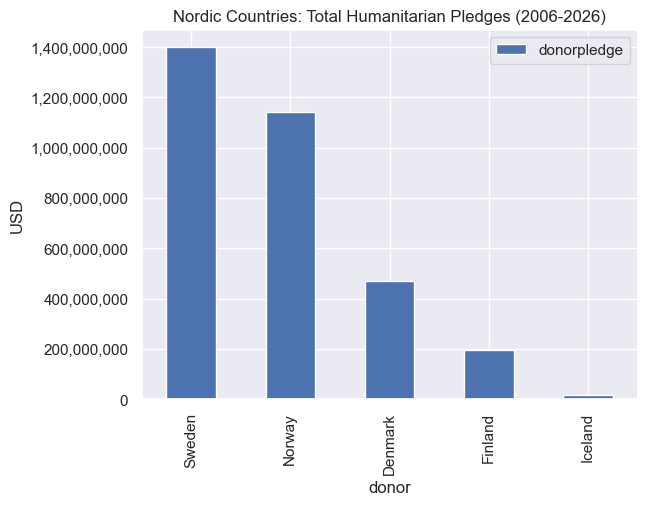

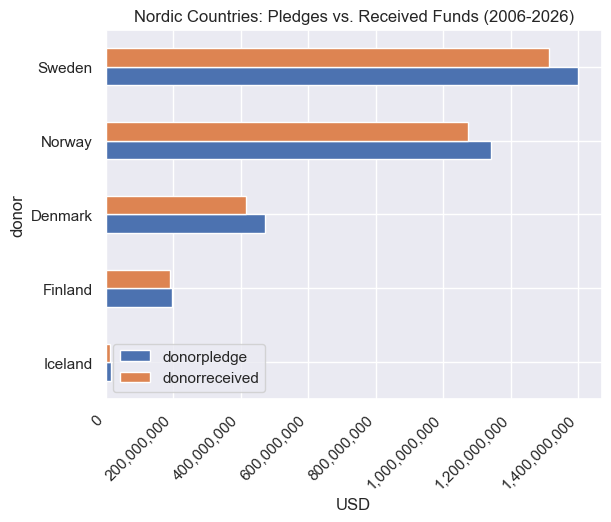

In [239]:
# c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect) continues
#This includes computing summary statistics (e.g. using .describe()) and creating at least 2 visualizations of the data. (1p)

import pandas as pd

pd.set_option('display.float_format', '{:.2f}'.format) # Without this, python is using scientific notation for large numbers. Claude provided this for me.
donor_contributions_df[["donorcommitment", "donorpledge", "donorreceived", "donorwriteoff"]].describe() 

#Donor Commitment: A formal, often written agreement (such as a contribution agreement) that solidifies the pledge, detailing the amount and terms.
#Donor Pledge: A public announcement or formal promise by a donor to provide funding for CERF. These are typically made at annual High-Level Pledging Events. For instance, in December 2024, 44 donors pledged $349 million for 2025.

#Received Funds: Cash contributions actually transferred to the CERF account. While pledges are high, actual received funding often differs. In 2021, $638 million was contributed against high demand.

#Took a subset of the Nordic countries
df_donor_nordic = donor_contributions_df[donor_contributions_df['donor'].isin(['Denmark', 'Finland', 'Iceland', 'Norway', 'Sweden'])]

nordic_sums = df_donor_nordic.groupby('donor')[['donorpledge','donorcommitment','donorreceived']].sum().reset_index()

display(nordic_sums)

#Chart 1
nordic_sums.sort_values('donorpledge', ascending=False, inplace=True)
ax=nordic_sums.plot(x='donor', y='donorpledge', kind='bar')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title("Nordic Countries: Total Humanitarian Pledges (2006-2026)")
plt.ylabel("USD")

#Chart 2
nordic_sums.sort_values('donorpledge',  inplace=True)

ax=nordic_sums.plot(x='donor', y=['donorpledge', 'donorreceived'], kind='barh')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.title("Nordic Countries: Pledges vs. Received Funds (2006-2026)")
plt.xlabel("USD")
plt.show()


### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [240]:
from dotenv import load_dotenv
import os

# Load all variables from .env into the environment

load_dotenv(override=True)

marketstack_api_key = os.environ.get("MARKETSTACK_API_KEY")

if marketstack_api_key:
    print(f"Key loaded: {marketstack_api_key[:5]}...")
else:
    print("ERROR: MARKETSTACK_API_KEY not found. Check your .env file.")

Key loaded: 724cc...


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [241]:
#a) Retrieve End-of-Day (eod) data for these five stocks for March 2026.

import requests

url ='https://api.marketstack.com/v2/eod'

params = {
	"access_key": marketstack_api_key,
    "symbols": "AMZN,META,AAPL,NFLX,GOOG",
    "date_from": '2026-03-01',
    "date_to": '2026-03-31'
}


request = requests.get(url, params)
print("Status code is")
print(request.status_code)

eod = request.json()
print(eod.keys())

print(type(eod))




Status code is
200
dict_keys(['pagination', 'data'])
<class 'dict'>


In [242]:

#b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.
import pandas as pd
eod_df =pd.DataFrame(eod['data'])

#eod_df.to_csv('eod_df.csv', index=False) #I saved the data in CSV so that if I need to restart the kernel, I do not need to do API calls.
#eod_df= pd.read_csv("eod_df.csv")

print(eod_df['name'].unique())
display(eod_df.head())
#display(eod_df.tail())
eod_df.dtypes


['Apple Inc' 'Amazon.com Inc' '1X GOOG' 'Meta Platforms, Inc.'
 'NETFLIX INC']


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,247.89,255.48,247.10,253.79,48770963.00,255.48,247.10,253.79,247.91,49598091.00,1.00,0.00,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.88,210.28,204.14,208.27,57843337.00,210.28,204.14,208.27,204.84,58470078.00,1.00,0.00,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.84,287.05,276.81,286.86,30680107.00,287.05,276.76,286.86,277.54,31625057.00,1.00,0.00,1X GOOG,None,ETF,EUR,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.98,573.69,546.77,572.13,32809500.00,573.69,546.77,572.13,549.98,32898272.00,1.00,0.00,"Meta Platforms, Inc.",None,Stock,ARS,META,ARCX,2026-03-31T00:00:00+0000
4,93.25,96.26,93.17,96.15,53674277.00,96.26,93.03,96.15,93.03,54269957.00,1.00,0.00,NETFLIX INC,None,None,MXN,NFLX,XNAS,2026-03-31T00:00:00+0000


open              float64
high              float64
low               float64
close             float64
volume            float64
adj_high          float64
adj_low           float64
adj_close         float64
adj_open          float64
adj_volume        float64
split_factor      float64
dividend          float64
name               object
exchange_code      object
asset_type         object
price_currency     object
symbol             object
exchange           object
date               object
dtype: object

In [246]:
#c) Compute summary statistics for the closing prices grouped by stock. 

#I will use describe() for the summary statistics
print("Summary statistics for closing price per stock:")
display(eod_df.groupby("name")["close"].describe()) #Claude helped me with this one: how to chain the name and close columns

# calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). 
#print(eod_df.groupby("name")["close"].first()) 
#print(eod_df.groupby("name")["close"].last())

#Here I retrieve the closing price for the last day of the month
last_day=eod_df.loc[eod_df['date'] == "2026-03-31T00:00:00+0000"].copy()
last_day_close=last_day[["close","name"]]
last_day_close=last_day_close.rename(columns={"close": "close_last"})
#display(last_day_close)

#Here I retrieve the closing price for the first day of the month
first_day=eod_df.loc[eod_df['date'] == "2026-03-04T00:00:00+0000"].copy()
first_day_close=first_day[["close","name"]]
first_day_close = first_day_close.rename(columns={"close": "close_first"})
#display(first_day_close)

# .copy() was added to avoid SettingWithCopyWarning which I originally got. When filtering a DataFrame with .loc[], 
# pandas sometimes returns a view of the original rather than an independent copy. 
# Modifying a view (e.g. renaming columns) can trigger this warning. 
# Using .copy() explicitly creates an independent copy, resolving the issue. (Claude helped me with the warning)

#Here I merge the two df's
df_inner=pd.merge(first_day_close, last_day_close, on="name", how='inner')

#Calculating the return percentage
df_inner['return_percentage'] = (df_inner['close_last'] - df_inner['close_first']) / df_inner['close_first'] *100
df_inner = df_inner[["name", "close_first", "close_last", "return_percentage"]]

#Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.
display(df_inner)

print("Netflix performed the best, as it had the least negative return with -2.54%. Meta performed the worst.")


Summary statistics for closing price per stock:


,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
1X GOOG,20.00,297.28,11.23,273.14,289.49,301.19,305.80,309.41
Amazon.com Inc,20.00,210.14,4.86,199.34,207.64,210.00,213.28,218.94
Apple Inc,20.00,253.97,4.84,246.63,250.07,252.85,258.06,262.52
"Meta Platforms, Inc.",20.00,611.06,41.32,525.72,593.47,614.69,645.49,667.73
NETFLIX INC,20.00,94.84,2.52,90.92,93.23,94.53,96.35,99.17


,name,close_first,close_last,return_percentage
0,Apple Inc,262.52,253.79,-3.33
1,Amazon.com Inc,216.82,208.27,-3.94
2,1X GOOG,303.45,286.86,-5.47
3,"Meta Platforms, Inc.",667.73,572.13,-14.32
4,NETFLIX INC,98.66,96.15,-2.54


Netflix performed the best, as it had the least negative return with -2.54%. Meta performed the worst.


### Task 3: Visualizing stock data (1p)



In [250]:
#Using the data from Task 2, create the following visualizations with seaborn:

#Install seaborn and other necessary libraries and packages
!pip install seaborn
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#First I will convert the date column into a date format
eod_df['date'] = pd.to_datetime(eod_df['date']) #I tried this first but claude recommended using the one below because then I 

#only get the date:
eod_df['date'] = eod_df['date'].dt.date
print("")
print("")
print(eod_df.dtypes)
display(eod_df.head())



open              float64
high              float64
low               float64
close             float64
volume            float64
adj_high          float64
adj_low           float64
adj_close         float64
adj_open          float64
adj_volume        float64
split_factor      float64
dividend          float64
name               object
exchange_code      object
asset_type         object
price_currency     object
symbol             object
exchange           object
date               object
dtype: object


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,247.89,255.48,247.10,253.79,48770963.00,255.48,247.10,253.79,247.91,49598091.00,1.00,0.00,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-31
1,204.88,210.28,204.14,208.27,57843337.00,210.28,204.14,208.27,204.84,58470078.00,1.00,0.00,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-31
2,277.84,287.05,276.81,286.86,30680107.00,287.05,276.76,286.86,277.54,31625057.00,1.00,0.00,1X GOOG,None,ETF,EUR,GOOG,XNAS,2026-03-31
3,549.98,573.69,546.77,572.13,32809500.00,573.69,546.77,572.13,549.98,32898272.00,1.00,0.00,"Meta Platforms, Inc.",None,Stock,ARS,META,ARCX,2026-03-31
4,93.25,96.26,93.17,96.15,53674277.00,96.26,93.03,96.15,93.03,54269957.00,1.00,0.00,NETFLIX INC,None,None,MXN,NFLX,XNAS,2026-03-31


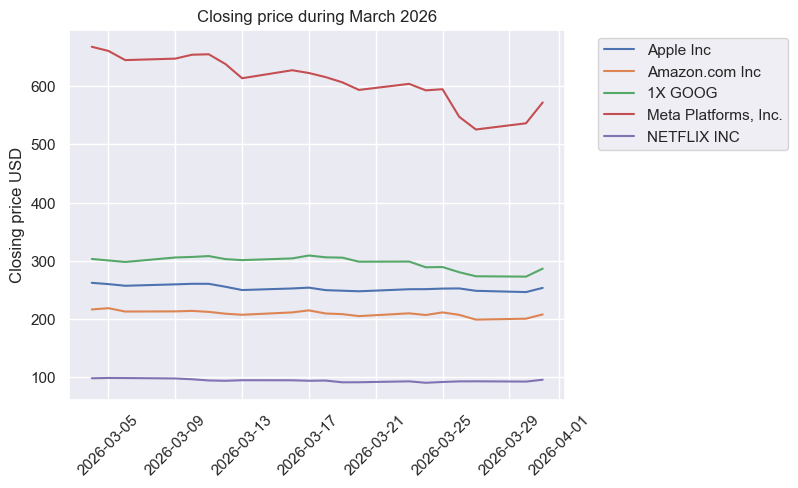

In [254]:
sns.set_theme(style="darkgrid")

#a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.
#https://seaborn.pydata.org/examples/errorband_lineplots.html

sns.lineplot(x="date", y="close",
             hue="name",
             data=eod_df)
plt.title("Closing price during March 2026")
plt.ylabel("Closing price USD")
plt.xticks(rotation=45)  # rotates x-axis labels to avoid overlap (provided by Claude)
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()





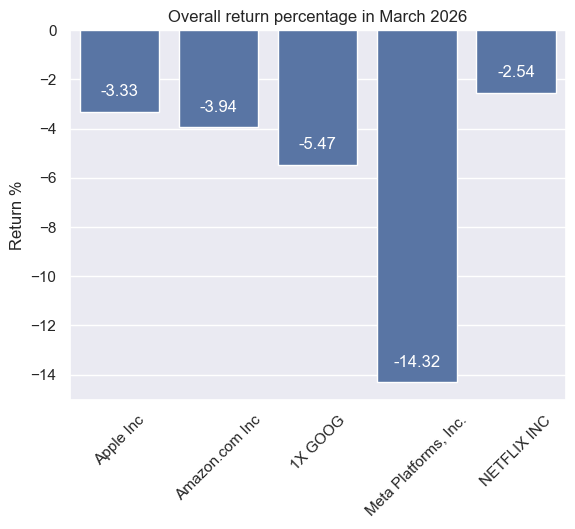

In [253]:

#b) A bar plot showing the overall return percentage for each stock in March 2026.
#display(df_inner)
ax = sns.barplot(x="name", y="return_percentage",
             data=df_inner)
plt.title("Overall return percentage in March 2026")
plt.ylabel("Return %")
plt.xlabel("")
plt.xticks(rotation=45)

#I wanted to make the visualisation a bit better so I added the data labels. This was provided by Claude: 
ax.bar_label(ax.containers[0], fmt='%.2f', label_type='edge', color='white', padding=-20)
plt.show()


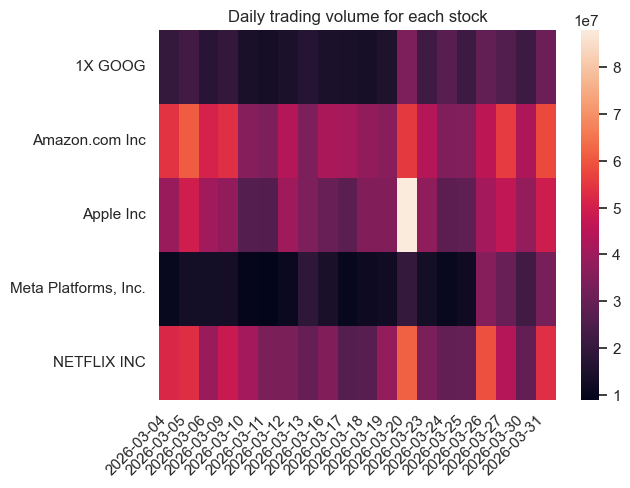

In [256]:
#c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

#https://seaborn.pydata.org/examples/spreadsheet_heatmap.html
eod_df_pivot = eod_df.pivot(index='name', columns='date', values='volume') #data needs to be in wide format
#display(eod_df_pivot)

sns.heatmap(eod_df_pivot)
plt.title("Daily trading volume for each stock")
plt.ylabel("")
plt.xlabel("")
plt.xticks(rotation=45)
plt.xticks(rotation=45, ha='right')
plt.show()

### Task 4: Exporting and importing data (1p)


In [258]:
#a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.
with open("exports/stockdata.json", "w") as f:
    json.dump(eod, f)

#b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.   

eod_df.to_csv('exports/stockdata.csv', index=False) 

eod_df= pd.read_csv("eod_df.csv")

#c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.
with open("exports/stockdata.json", "r") as f:
    stockdata_json = json.load(f)

print("Loading back the stockdata in json")
print(stockdata_json['data'][:5]) #Claude helped me with this one
print(type(stockdata_json))

print("")
print("")
print("Loading back the stockdata in CSV")
stockdata_csv= pd.read_csv("exports/stockdata.csv")
print(stockdata_csv.head())

Loading back the stockdata in json
[{'open': 247.89, 'high': 255.48, 'low': 247.101, 'close': 253.79, 'volume': 48770963.0, 'adj_high': 255.48, 'adj_low': 247.101, 'adj_close': 253.79, 'adj_open': 247.91, 'adj_volume': 49598091.0, 'split_factor': 1.0, 'dividend': 0.0, 'name': 'Apple Inc', 'exchange_code': 'NASDAQ', 'asset_type': 'Stock', 'price_currency': 'USD', 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}, {'open': 204.875, 'high': 210.28, 'low': 204.14, 'close': 208.27, 'volume': 57843337.0, 'adj_high': 210.28, 'adj_low': 204.14, 'adj_close': 208.27, 'adj_open': 204.845, 'adj_volume': 58470078.0, 'split_factor': 1.0, 'dividend': 0.0, 'name': 'Amazon.com Inc', 'exchange_code': 'NASDAQ', 'asset_type': 'Stock', 'price_currency': 'USD', 'symbol': 'AMZN', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}, {'open': 277.84, 'high': 287.05, 'low': 276.81, 'close': 286.86, 'volume': 30680107.0, 'adj_high': 287.05, 'adj_low': 276.76, 'adj_close': 286.86, 'adj

### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

In [260]:
#Download an SQLite version of Microsoft's Northwind database 
#(from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.



import sqlite3

con = sqlite3.connect("northwind.db")

cur = con.cursor()

#a) #Connect to the database and list all tables it contains (print the table names).
res =cur.execute("SELECT name FROM sqlite_master WHERE type='table'")

print("Tables:")
print(res.fetchall())

#b) Write a SQL query that retrieves all products with a unit price above 30, 
#showing ProductName, UnitPrice, and UnitsInStock. Load the result into a DataFrame and print it.

over30_df = pd.read_sql_query("SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30", con)

print("")
print("")
print("")
print("Shape:", over30_df.shape)
print(over30_df)


#c)  Dataframe to show all products shipped to Germany 

#The SQL code was provided by Claude:

df = pd.read_sql_query("""SELECT c.CompanyName, o.OrderID, o.OrderDate, o.ShipCountry, od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'""", con)

print("")
print("")
print("")
display(df)


Tables:
[('Categories',), ('sqlite_sequence',), ('CustomerCustomerDemo',), ('CustomerDemographics',), ('Customers',), ('Employees',), ('EmployeeTerritories',), ('Order Details',), ('Orders',), ('Products',), ('Regions',), ('Shippers',), ('Suppliers',), ('Territories',)]



Shape: (24, 3)
                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.40
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.00
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.20
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.00
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.00
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.00
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.00
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.00
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.00


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:


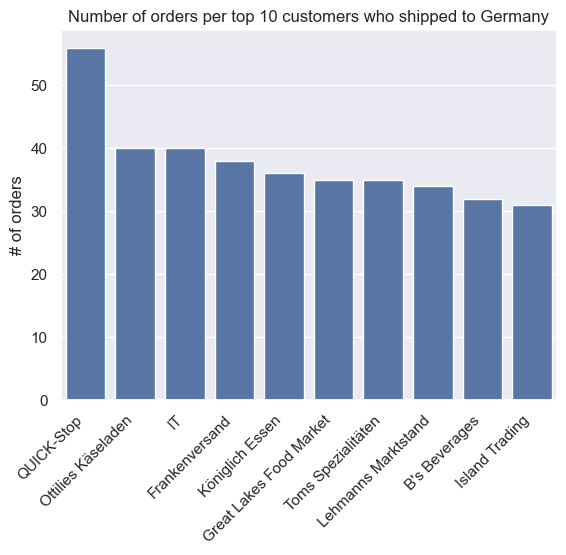

In [265]:
#a) Using the result from Task 5c, create a bar plot showing the number of orders per customer 
#(for the top 10 customers who shipped to Germany).

#display(df.head())

df2 = df.groupby('CompanyName')['OrderID'].nunique().reset_index()

#print("Grouped by Company name with count of orderIDs")
#display(df2)

df2_sorted = df2.sort_values(by='OrderID', ascending=False)
#display(df2_sorted)

df2_10=df2_sorted.head(10)
#display(df2_10)

sns.barplot(df2_10, x="CompanyName", y="OrderID")
plt.xlabel("")
plt.title("Number of orders per top 10 customers who shipped to Germany")
plt.ylabel("# of orders")
plt.xticks(rotation=45, ha='right')
plt.show()

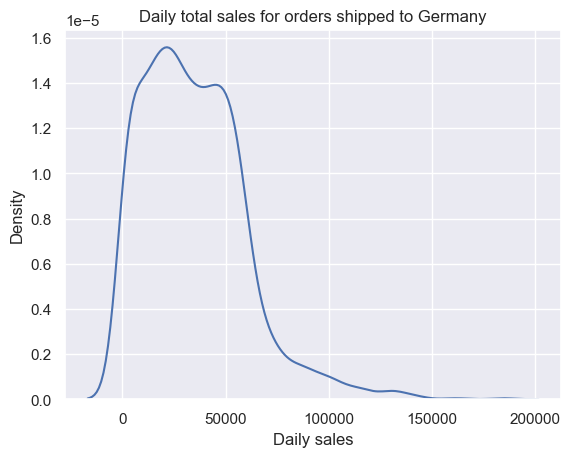

Most daily sales cluster between 0 and 75,000, with a long tail to the right indicating some days with very high sales volumes.


In [281]:
#b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of 
#daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, 
#i.e., makes it easy to see the typical size of daily sales volumes.

#display(df.head())
#Convert OrderDate to date:

df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed') #I tried this first but claude recommended using the one below because then I 

#only get the date:
df['OrderDate'] = df['OrderDate'].dt.date

#Compute the sales per order date
daily_sales=df.groupby('OrderDate')['LineTotal'].sum().reset_index()
#display(daily_sales)

sns.kdeplot(data=daily_sales, 
           x="LineTotal")
plt.title("Daily total sales for orders shipped to Germany")
plt.xlabel("Daily sales")
plt.show()

print("Most daily sales cluster between 0 and 75,000, with a long tail to the right indicating some days with very high sales volumes.")

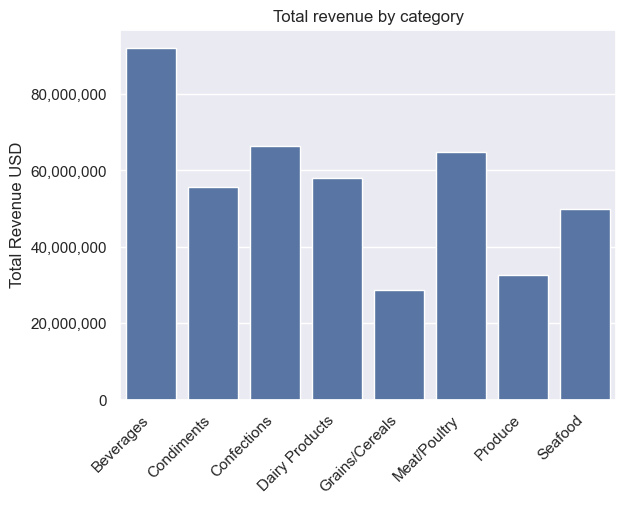

In [282]:
#c) Write a new SQL query that joins OrderDetails, Products, and Categories using 
#inner joins to compute the total revenue (UnitPrice * Quantity) per product category. 
#Load the result into a DataFrame and create a bar plot showing total revenue by category.


#Claude provided me the SQL query:
df_c = pd.read_sql_query("""SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName""", con)

#display(df_c)

ax=sns.barplot(df_c, x="CategoryName", y="TotalRevenue")
plt.xlabel("")
plt.title("Total revenue by category")
plt.ylabel("Total Revenue USD")
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) #Claude helped me with this one. Python is 
#using scientific notation to represent large numbers and I wanted to have numbers



### Task 7: Comparing Python to SQL (1p)

In [287]:
#a) Write a SQL query that retrieves the full Products table and the full Categories table into separate DataFrames. 
#Print the first 5 rows of each.


df_products = pd.read_sql_query("""SELECT * FROM Products""", con)
df_categories = pd.read_sql_query("""SELECT * FROM Categories""", con)

print("The first 5 rows of the Products table")
display(df_products.head())
print("")
print("The first 5 rows of the Categories table")
display(df_categories.head())

#b) Using pandas, perform an inner join on the two DataFrames from 7a on CategoryID.
df_inner7=pd.merge(df_products, df_categories, on="CategoryID", how='inner')

print("")
print("The inner join")
display(df_inner7.head())

The first 5 rows of the Products table


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1



The first 5 rows of the Categories table


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...



The inner join


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [285]:
#c) Replicate with Python the SQL code of Task 6c, retrieving first the tables 
#fully using SQL and joining them with pandas. Using %%time or time.time(), 
#compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in 
#Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). 
#Print both execution times and briefly comment on which was faster

import time 
start = time.time()
df_c_new = pd.read_sql_query("""SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName""", con)

display(df_c_new)
end = time.time()
print(f"Execution time for SQL join: {end - start:.4f} seconds")


start = time.time()
df_products = pd.read_sql_query("""SELECT * FROM Products""", con)
df_categories = pd.read_sql_query("""SELECT * FROM Categories""", con)
df_order = pd.read_sql_query("""SELECT * FROM 'Order Details'""", con)

#display(df_order)
df_innerx=pd.merge(df_order, df_products, on="ProductID", how='inner')
df_innery=pd.merge(df_innerx, df_categories, on="CategoryID", how='inner')

#print("innerx")
#display(df_innerx)

df_innery['TotalRevenue']=df_innery.UnitPrice_x *df_innery.Quantity
#display(df_innery.head())

df_innery_tr = df_innery.groupby('CategoryName')[['TotalRevenue']].sum().reset_index()
display(df_innery_tr)
#print("innery")

end = time.time()
print(f"Execution time for pandas join: {end - start:.4f} seconds")


print("")
print("""SQL is much faster in this task. I guess it is because SQL is developed for these kinds of tasks: Data retrieval 
and small tasks, whereas pandas is meant for data manipulation""")

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


Execution time for SQL join: 1.2121 seconds


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


Execution time for pandas join: 2.4819 seconds

SQL is much faster in this task. I guess it is because SQL is developed for these kinds of tasks: Data retrieval 
and small tasks, whereas pandas is meant for data manipulation


### Task 8: Wide and long format (1p)

In [288]:
import pandas as pd
#You are given two datasets. The first is in wide format:

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

#The second is in long format:
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

print("wide data")
display(wide_data)
print("")
print("long format")
display(long_data)

wide data


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500



long format


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


In [289]:
#a) Convert wide_data from wide to long format using pd.melt(). Print the DataFrame before and after conversion.

wide_to_long = pd.melt(wide_data, id_vars=["store"], value_vars= ["Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"],  var_name="quarter", value_name="sales") 
print("Original wide_data dataframe")
display(wide_data)
print(" ")
print("Converted data frame in long format")
display(wide_to_long)



Original wide_data dataframe


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


 
Converted data frame in long format


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [291]:
#b) Convert long_data from long to wide format using .pivot(). Print the DataFrame before and after conversion.

print("Original long format")
display(long_data)
long_pivot = long_data.pivot(index="month", columns="product", values="units_sold")
long_pivot = long_pivot.reset_index()
long_pivot.columns.name = None

print("Converted wide format")
display(long_pivot)

Original long format


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


Converted wide format


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [292]:
#c) Convert both transformed datasets back to their original format. 
#Print the datasets before and after to confirm they match the originals.

#wide format converted back to the original long format

display(wide_data)
display(wide_to_long)
wide_pivot = wide_to_long.pivot(index="store", columns="quarter", values="sales")
wide_pivot.columns.name = None
print(" ")
print("Conversion back to the original - they match")

display(wide_pivot)



,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


 
Conversion back to the original - they match


,Q1_sales,Q2_sales,Q3_sales,Q4_sales
store,,,,
Helsinki,12000,13500,11800,15000
Tampere,8500,9100,8800,10200
Turku,9200,9800,10100,11500


In [221]:
#c) Convert both transformed datasets back to their original format.

#long format converted back to the original wide format
display(long_data)
print("")

display(long_pivot)
wide_to_original = pd.melt(long_pivot, id_vars=["month"], value_vars= ["Laptop", "Phone"],  var_name="product", value_name="units_sold")

display(wide_to_original)

,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130
